In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

diabetes_data = pd.read_csv("./data/diabetes.csv")
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('Confusion Matrix', confusion)
    print(accuracy, precision, recall, f1, roc_auc)

In [4]:
def precision_recall_curve_plot(y_test=None, pred_prob_c1=None):
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_prob_c1)
    plt.figure(figsize=(8, 6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary], linestyle='--', label='recall')

    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))

    plt.xlabel('threshold values')
    plt.ylabel('precision, recalls value')
    plt.legend()
    plt.grid()
    plt.show()

In [8]:
X = diabetes_data.iloc[:, :-1]
y = diabetes_data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state = 42,
                                                    stratify = y)

lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, pred, pred_proba)

Confusion Matrix [[79 21]
 [24 30]]
0.7077922077922078 0.5882352941176471 0.5555555555555556 0.5714285714285714 0.83


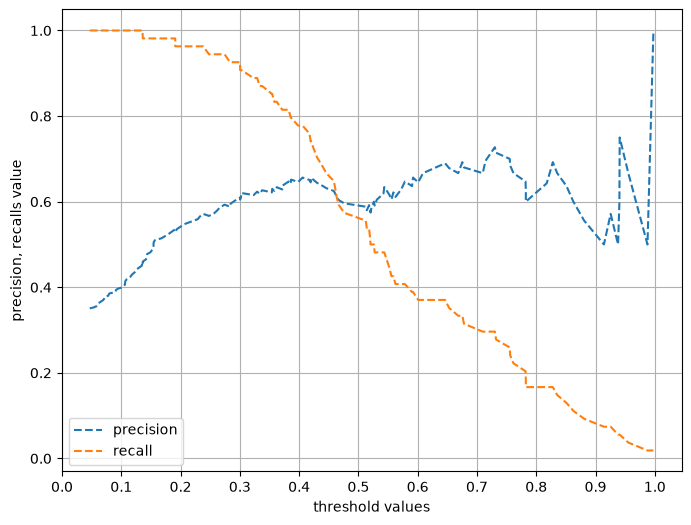

In [9]:
pred_proba_c1 = lr_clf.predict_proba(X_test)[:, 1]
precision_recall_curve_plot(y_test, pred_proba_c1)

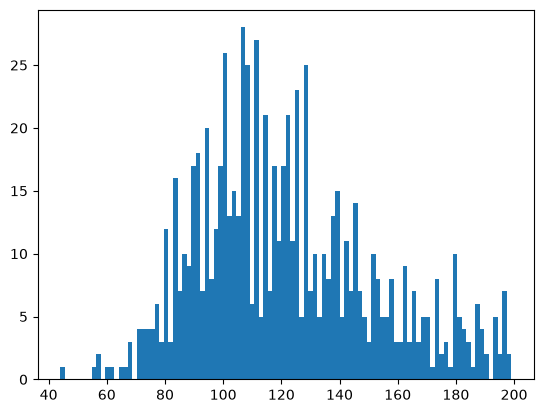

In [13]:
plt.hist(diabetes_data['Glucose'], bins=100)
plt.show()

In [16]:
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness','Insulin', 'BMI']

total_count = diabetes_data['Glucose'].count()

for feature in zero_features:
    zero_count = diabetes_data[diabetes_data[feature] == 0][feature].count()
    print(feature)
    print(zero_count)
    print((zero_count/total_count)*100)

Glucose
0
0.0
BloodPressure
0
0.0
SkinThickness
0
0.0
Insulin
0
0.0
BMI
0
0.0


In [17]:
# 결측치 처리
mean_zero_features = diabetes_data[zero_features].mean()
diabetes_data[zero_features] = diabetes_data[zero_features].replace(0, mean_zero_features)

In [18]:
X = diabetes_data.iloc[:, :-1]
y = diabetes_data.iloc[:, -1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,
                                                    test_size=0.2, random_state = 42, stratify = y)

lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, pred, pred_proba)

Confusion Matrix [[79 21]
 [24 30]]
0.7077922077922078 0.5882352941176471 0.5555555555555556 0.5714285714285714 0.8262962962962963


In [19]:
from sklearn.preprocessing import Binarizer

def get_eval_by_threshold(y_test, pred_prob_c1, thresholds):
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold = custom_threshold).fit(pred_prob_c1)
        custom_predict = binarizer.transform(pred_prob_c1)
        print('임계값 :', custom_threshold)
        get_clf_eval(y_test, custom_predict, pred_proba_c1)

In [20]:
thresholds = [0.3, 0.33, 0.36, 0.39, 0.42, 0.45, 0.48, 0.50]
pred_proba = lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test, pred_proba[:,1].reshape(-1, 1), thresholds)

임계값 : 0.3
Confusion Matrix [[70 30]
 [ 6 48]]
0.7662337662337663 0.6153846153846154 0.8888888888888888 0.7272727272727273 0.83
임계값 : 0.33
Confusion Matrix [[72 28]
 [ 8 46]]
0.7662337662337663 0.6216216216216216 0.8518518518518519 0.71875 0.83
임계값 : 0.36
Confusion Matrix [[74 26]
 [14 40]]
0.7402597402597403 0.6060606060606061 0.7407407407407407 0.6666666666666666 0.83
임계값 : 0.39
Confusion Matrix [[75 25]
 [15 39]]
0.7402597402597403 0.609375 0.7222222222222222 0.6610169491525424 0.83
임계값 : 0.42
Confusion Matrix [[76 24]
 [19 35]]
0.7207792207792207 0.5932203389830508 0.6481481481481481 0.6194690265486725 0.83
임계값 : 0.45
Confusion Matrix [[77 23]
 [21 33]]
0.7142857142857143 0.5892857142857143 0.6111111111111112 0.6 0.83
임계값 : 0.48
Confusion Matrix [[79 21]
 [23 31]]
0.7142857142857143 0.5961538461538461 0.5740740740740741 0.5849056603773585 0.83
임계값 : 0.5
Confusion Matrix [[79 21]
 [24 30]]
0.7077922077922078 0.5882352941176471 0.5555555555555556 0.5714285714285714 0.83
